In [1]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import yaml


In [2]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [3]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

# データ読み込み

In [4]:
dict_dtype_station = {
    "station_id": "int64",
    "lat": "float64",
    "long": "float64",
    "dock_count": "int64",
    "city": "object",
    "installation_date": "object",
}
dict_dtype_status = {
    "id": "int64",
    "year": "int64",
    "month": "int64",
    "day": "int64",
    "hour": "int64",
    "station_id": "int64",
    "bikes_available": "float64",
    "predict": "int64",
}
dict_dtype_trip = {
    "trip_id": "int64",
    "duration": "int64",
    "start_date": "object",
    "start_station_id": "int64",
    "end_date": "object",
    "end_station_id": "int64",
    "bike_id": "int64",
    "subscription_type": "object",
}
dict_dtype_weather = {
    "date": "object",
    "max_temperature": "int64",
    "mean_temperature": "int64",
    "min_temperature": "int64",
    "max_dew_point": "int64",
    "mean_dew_point": "int64",
    "min_dew_point": "int64",
    "max_humidity": "int64",
    "mean_humidity": "int64",
    "min_humidity": "int64",
    "max_sea_level_pressure": "float64",
    "mean_sea_level_pressure": "float64",
    "min_sea_level_pressure": "float64",
    "max_visibility": "int64",
    "mean_visibility": "int64",
    "min_visibility": "int64",
    "max_wind_Speed": "int64",
    "mean_wind_speed": "int64",
    "precipitation": "float64",
    "cloud_cover": "int64",
    "events": "object",
    "wind_dir_degrees": "int64",
}

In [5]:
df_station = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATION), dtype=dict_dtype_station)
df_status = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATUS), dtype=dict_dtype_status)
df_trip = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_TRIP), dtype=dict_dtype_trip)
df_weather = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_WEATHER), dtype=dict_dtype_weather)

# 前処理

In [16]:
def convert_datetime(df_station, df_status, df_trip, df_weather):
    df_station["installation_date"] = pd.to_datetime(df_station["installation_date"], format='%m/%d/%Y').dt.date
    df_status["datetime"] = pd.to_datetime(df_status[["year", "month", "day", "hour"]])
    df_trip["start_date"] = pd.to_datetime(df_trip["start_date"], format='%m/%d/%Y %H:%M')
    df_trip["end_date"] = pd.to_datetime(df_trip["end_date"], format='%m/%d/%Y %H:%M')
    df_weather["date"] = pd.to_datetime(df_weather["date"], format='%Y-%m-%d').dt.date

    return df_station, df_status, df_trip, df_weather

In [17]:
df_station, df_status, df_trip, df_weather = convert_datetime(df_station, df_status, df_trip, df_weather)

In [18]:
# データ出力
df_station.to_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
df_status.to_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_trip.to_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_weather.to_pickle(os.path.join(DIR_INTERIM, "df_prep_weather.pkl"))

# 特徴量作成

In [19]:
from pathlib import Path
from abc import ABCMeta, abstractmethod

In [20]:
from time import time

def decorate(s: str, decoration=None):
    if decoration is None:
        decoration = '★' * 20
        
    return ' '.join([decoration, str(s), decoration])

class Timer:
    def __init__(self, logger=None, format_str='{:.3f}[s]', prefix=None, suffix=None, sep=' ', verbose=0):

        if prefix: format_str = str(prefix) + sep + format_str
        if suffix: format_str = format_str + sep + str(suffix)
        self.format_str = format_str
        self.logger = logger
        self.start = None
        self.end = None
        self.verbose = verbose

    @property
    def duration(self):
        if self.end is None:
            return 0
        return self.end - self.start

    def __enter__(self):
        self.start = time()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end = time()
        if self.verbose is None:
            return
        out_str = self.format_str.format(self.duration)
        if self.logger:
            self.logger.info(out_str)
        else:
            print(out_str)

In [21]:
class AbstractBaseBlock(metaclass=ABCMeta):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        self.use_cache = use_cache
        self.name = self.__class__.__name__
        self.cache_dir = Path(DIR_FEATURE)
        self.logger = logger
        self.seve_cache = save_cache
        self.use_cols = None
        
    # 内部状態の更新
    def fit(self, df_input: pd.DataFrame, y=None):
        pass
    
    # 変換処理
    @abstractmethod
    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        raise NotImplementedError()
    
    # 内部状態の更新と変換処理をまとめて行う
    def fit_transform(self, X: pd.DataFrame, y=None):
        self.fit(X, y)
        return self.transform(X)
    
    # 特徴量生成処理
    def create_feature(self, X, y=None, test=False, limit_date="yyyy-mm-dd") -> pd.DataFrame:

        # クラス名.pkl
        file_name = os.path.join(self.cache_dir, limit_date, f"{self.name}.pkl")

        # キャッシュを使う & ファイルがあるなら読み出し
        if os.path.isfile(str(file_name)) and self.use_cache:
            return pd.read_pickle(file_name)
        
        # 変換処理を実行
        else:
            # trainの場合
            if not test:
                feature = self.fit_transform(X, y)
            # testの場合
            else:
                feature = self.transform(X)
            # 保存する場合
            if self.seve_cache:
                feature.to_pickle(file_name)

            return feature

In [22]:
# そのままの特徴量を返すBlock

In [23]:
# 静的特徴量
# 動的特徴量

In [24]:
class AsIsNumetricBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'CityTier', 
            'DurationOfPitch',
            'NumberOfPersonVisiting',
            'NumberOfFollowups', 
            'PreferredPropertyStar', 
            'NumberOfTrips',
            'Passport', 
            'PitchSatisfactionScore',
            'MonthlyIncome', 
            'ProdTaken' # 目的関数
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

class AsIsCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'Age', 
            'TypeofContact',
            'Occupation',
            'Gender',
            'ProductPitched',
            'Designation', 
            'customer_info', 
            'marry', 
            'car', 
            'child',
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

In [25]:
class CountEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_count = None

    def fit(self, df_input, y=None):
        # カラムごとにマッピング表を作成
        self.map_count = {}
        for col in self.use_cols:
            self.map_count[col] = df_input[col].fillna("NA").value_counts()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].fillna("NA").map(self.map_count[col]).astype(int)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('CE_')], axis=1)
        return df_result
        
class TargetEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y):
        # カラムごとにマッピング表を作成
        self.map_target = {}
        for col in self.use_cols:
            self.map_target[col] = df_input.groupby(col)[TARGET_COL].mean()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].map(self.map_target[col]).astype(float)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('TE_')], axis=1)
        return df_result
    
# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result
    
    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result
    
# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result
    
    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result

In [26]:
def run_blocks(df_input, feature_blocks, y=None, test=False):
    df_out = None
    
    print(decorate('start run blocks...'))

    with Timer(prefix='run test={}'.format(test)):
        for block in feature_blocks:
            with Timer(prefix='\t- {}'.format(str(block))):
                feature = block.create_feature(df_input, y=y, test=test)
            assert len(df_input) == len(feature), block
            if df_out is None:
                df_out = feature
            else:
                df_out = pd.merge(df_out, feature, on=["id"], how="left")

    return df_out

In [27]:
feature_blocks = [
    *[AsIsCategoryBlock(use_cache=False, save_cache=True, logger=None)],
    *[AsIsNumetricBlock(use_cache=True, save_cache=True, logger=None)],
    *[CountEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[TargetEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[BigCategoryBlock(use_cache=True, save_cache=True, logger=None)],
]

In [ ]:
df_preprocessed = pd.read_pickle(os.path.join(DIR_INTERIM, "preprocessed.pkl"))

In [212]:
df_out = run_blocks(df_preprocessed, feature_blocks, y=None, test=False)

★★★★★★★★★★★★★★★★★★★★ start run blocks... ★★★★★★★★★★★★★★★★★★★★
	- <__main__.AsIsCategoryBlock object at 0x7fd57ad0a400> 0.034[s]
	- <__main__.AsIsNumetricBlock object at 0x7fd57ad0a8b0> 0.004[s]
	- <__main__.CountEncodingBlock object at 0x7fd57ad0a8e0> 0.002[s]
	- <__main__.TargetEncodingBlock object at 0x7fd57ad0a940> 0.001[s]
	- <__main__.BigCategoryBlock object at 0x7fd57ad0ac70> 0.001[s]
run test=False 0.069[s]


# 特徴量生成

In [5]:
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))

In [6]:
df_prep_status.head()

,id,year,month,day,hour,station_id,bikes_available,predict,datetime
0,0,2013,9,1,0,0,11.0,0,2013-09-01 00:00:00
1,1,2013,9,1,1,0,11.0,0,2013-09-01 01:00:00
2,2,2013,9,1,2,0,11.0,0,2013-09-01 02:00:00
3,3,2013,9,1,3,0,11.0,0,2013-09-01 03:00:00
4,4,2013,9,1,4,0,11.0,0,2013-09-01 04:00:00


In [7]:
# keyデータの作成
df_key = df_prep_status[["station_id", "datetime"]].copy()

In [65]:
# 目的変数
df_target = df_prep_status[["station_id", "datetime", "bikes_available"]].copy()

In [8]:
# predictデータの作成
df_predict = df_prep_status[["station_id", "datetime", "predict"]].copy()

In [9]:
# 欠損値補完した時系列データの作成
df_timeseries = df_prep_status[["station_id", "datetime", "predict", "bikes_available"]].copy()
#各ステーション毎に、欠損値を埋める
df_timeseries_fillna = pd.DataFrame()
for station_id in df_timeseries["station_id"].unique().tolist():
    temp_df = df_timeseries[df_timeseries["station_id"]==station_id]
    # 前の値で欠損値補完
    temp_df = temp_df.ffill()
    # predict==1のデータをnullにする
    temp_df.loc[temp_df["predict"]==1, "bikes_available"] = np.nan
    df_timeseries_fillna = pd.concat([df_timeseries_fillna,temp_df])
df_timeseries_fillna.drop(columns=["predict"], inplace=True)

print(df_timeseries[["bikes_available"]].isnull().sum())
print(df_timeseries_fillna[["bikes_available"]].isnull().sum())

bikes_available    218522
dtype: int64
bikes_available    214805
dtype: int64


In [18]:
# ラグ特徴量の作成
df_lag = df_prep_status.copy()[["station_id", "datetime", "bikes_available"]]
lags = 24
target_col = "bikes_available"
for i in range(0, lags+1):
    df_shift = df_prep_status[["station_id", "datetime", target_col]].copy()
    df_shift["datetime"] = df_shift["datetime"] + pd.Timedelta(hours=i)
    df_shift.columns = ["station_id", "datetime", f"{target_col}_lag{i}"]
    df_lag = pd.merge(df_lag, df_shift, on=["station_id", "datetime"], how="left")
df_lag = df_lag.drop(columns=target_col)

In [21]:
# 曜日特徴量の作成
df_weekday = df_prep_status.copy()[["datetime"]].drop_duplicates()
df_weekday["weekday"] = df_weekday["datetime"].dt.weekday

# モデル別データセットを作成

In [66]:
# LGBM用データセット
df_main_lgb = df_key.copy()
df_main_lgb = pd.merge(df_main_lgb, df_target, on=["station_id","datetime"], how="left")
df_main_lgb = pd.merge(df_main_lgb, df_predict, on=["station_id","datetime"], how="left")
df_main_lgb = pd.merge(df_main_lgb, df_lag, on=["station_id","datetime"], how="left")
df_main_lgb = pd.merge(df_main_lgb, df_weekday, on=["datetime"], how="left")

In [67]:
df_main_lgb.head()

,station_id,datetime,bikes_available,predict,bikes_available_lag0,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,...,bikes_available_lag16,bikes_available_lag17,bikes_available_lag18,bikes_available_lag19,bikes_available_lag20,bikes_available_lag21,bikes_available_lag22,bikes_available_lag23,bikes_available_lag24,weekday
0,0,2013-09-01 00:00:00,11.0,0,11.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
1,0,2013-09-01 01:00:00,11.0,0,11.0,11.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
2,0,2013-09-01 02:00:00,11.0,0,11.0,11.0,11.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
3,0,2013-09-01 03:00:00,11.0,0,11.0,11.0,11.0,11.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
4,0,2013-09-01 04:00:00,11.0,0,11.0,11.0,11.0,11.0,11.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6


In [24]:
# LSTM用データセット
df_main_lstm = df_key.copy()
df_main_lstm = pd.merge(df_main_lstm, df_predict, on=["station_id","datetime"], how="left")
df_main_lstm = pd.merge(df_main_lstm, df_timeseries_fillna, on=["station_id","datetime"], how="left")
df_main_lstm = pd.merge(df_main_lstm, df_weekday, on=["datetime"], how="left")

In [26]:
df_main_lstm.head()

,station_id,datetime,predict,bikes_available,weekday
0,0,2013-09-01 00:00:00,0,11.0,6
1,0,2013-09-01 01:00:00,0,11.0,6
2,0,2013-09-01 02:00:00,0,11.0,6
3,0,2013-09-01 03:00:00,0,11.0,6
4,0,2013-09-01 04:00:00,0,11.0,6


# 検証用データセット化

In [27]:
# 検証データにフラグを立てる
def create_valid_flag(df_result):
    # テストデータと2日以上離れているデータを検証データとする
    df_ = df_result.copy()
    df_ = df_[df_["predict"] != 0]
    df_["date"] = df_["datetime"].dt.date
    df_ = df_[["date","predict"]].drop_duplicates()
    df_["diff"] = df_["date"].diff().dt.days
    df_["yesterday"] = df_["date"].apply(lambda x: x - pd.Timedelta(days=1))
    list_valid_date = df_[df_["diff"] >= 4.0]["yesterday"].tolist()
    # dateがlist_valid_dateに含まれている場合はpredictを2にする
    df_result_ = df_result.copy()
    df_result_["predict"] = df_result_.apply(lambda x: 2 if (x["datetime"].date() in list_valid_date) & (x["datetime"].hour!=0) else x["predict"], axis=1)
    return df_result_

def create_add_valid_dataset(df_main):
    """検証データのフラグを立てる
    """
    df_main_ = df_main.copy()
    df_main_ = df_main_.sort_values(["datetime","station_id"],ascending=True).reset_index(drop=True)
    past_2_len = 0
    while True:
        df_main_ = create_valid_flag(df_main_)
        current_2_len = len(df_main_[df_main_["predict"] == 2])
        if current_2_len == past_2_len:
            break
        past_2_len = current_2_len

    return df_main_

In [68]:
df_main_lgb_new = create_add_valid_dataset(df_main_lgb)

In [69]:
df_main_lgb_new.groupby("predict").size()

predict
0    928550
1    193200
2    104650
dtype: int64

In [29]:
df_main_lstm_new = create_add_valid_dataset(df_main_lstm)

In [30]:
df_main_lstm_new.groupby("predict").size()

predict
0    928550
1    193200
2    104650
dtype: int64

In [70]:
df_main_lstm_new.to_pickle(os.path.join(DIR_INTERIM, "df_main_lstm_new.pkl"))
df_main_lgb_new.to_pickle(os.path.join(DIR_INTERIM, "df_main_lgb_new.pkl"))

# LightGBM

In [4]:
df_main_lgb_new = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lgb_new.pkl"))

In [5]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from datetime import datetime
from src.util import Logger

/Users/ishizuka/opt/anaconda3/envs/mufgcup2024/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [7]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [8]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

In [9]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel")
run_name = 'lgbm_multimodel_202410132324'
run_name

'lgbm_multimodel_202410132324'

In [10]:
model_params = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 2000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [11]:
memo = "LightGBM23期マルチモデル regression_l1に変更"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel, 
    model_params, 
    df_main_lgb_new, 
    run_setting, 
    cv_setting, 
    logger, 
    memo)

In [12]:
ml_runner.run_train_cv()

[2024-10-14 00:30:40] - lgbm_multimodel_202410132324 - start training cv
[2024-10-14 00:30:40] - lgbm_multimodel_202410132324 fold 2014-09-01 - start training


1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
create dataset
start train
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 704
[LightGBM] [Info] Number of data points in the train set: 22398, number of used features: 26
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.24859	eval's l1: 1.41178
[200]	train's l1: 0.597181	eval's l1: 0.695925
[300]	train's l1: 0.409838	eval's l1: 0.491844
[400]	train's l1: 0.333588	eval's l1: 0.406805
[500]	train's l1: 0.253587	eval's l1: 0.306075
[600]	train's l1: 0.206674	eval's l1: 0.242996
[700]	train's l1: 0.1911

In [243]:
ml_runner.run_metric_cv()

[2024-10-13 19:06:10] - lgbm_multimodel_202410131842 - start metric cv
100%|██████████| 12/12 [02:52<00:00, 14.35s/it]
memo: LightGBM23期マルチモデル regression_l1に変更
run_name:lgbm_multimodel_202410131842	score_mean:1.594984148254511	score0:1.6904419519555196	score1:1.799390365592905	score2:1.5548695711353593	score3:1.5492193183227942	score4:1.5753478417067914	score5:1.3940754138276519	score6:1.6003376664495323	score7:1.536784674518074	score8:1.5352274172334583	score9:1.660335124469321	score10:1.691602873038414	score11:1.552177560804312
mean: 1.594984148254511, std: 0.09906758418574224
[2024-10-13 19:09:02] - mean: 1.594984148254511, std: 0.09906758418574224
[2024-10-13 19:09:02] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multimodel_202410131842/va_pred.pkl
[2024-10-13 19:09:02] - lgbm_multimodel_202410131842 - end metric cv


In [60]:
ml_runner.run_predict_cv()

[2024-10-13 23:06:01] - lgbm_multimodel_202410131842 - start prediction cv
  0%|          | 0/12 [00:11<?, ?it/s]


KeyError: "['bikes_available'] not in index"

In [269]:
ml_runner.plot_feature_importance_cv()

[2024-10-13 20:11:46] - lgbm_multimodel_202410131842 - start plot feature importance cv
[2024-10-13 20:12:23] - lgbm_multimodel_202410131842 - end plot feature importance cv


In [ ]:
# 予測値確認

In [245]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル regression_l1に変更


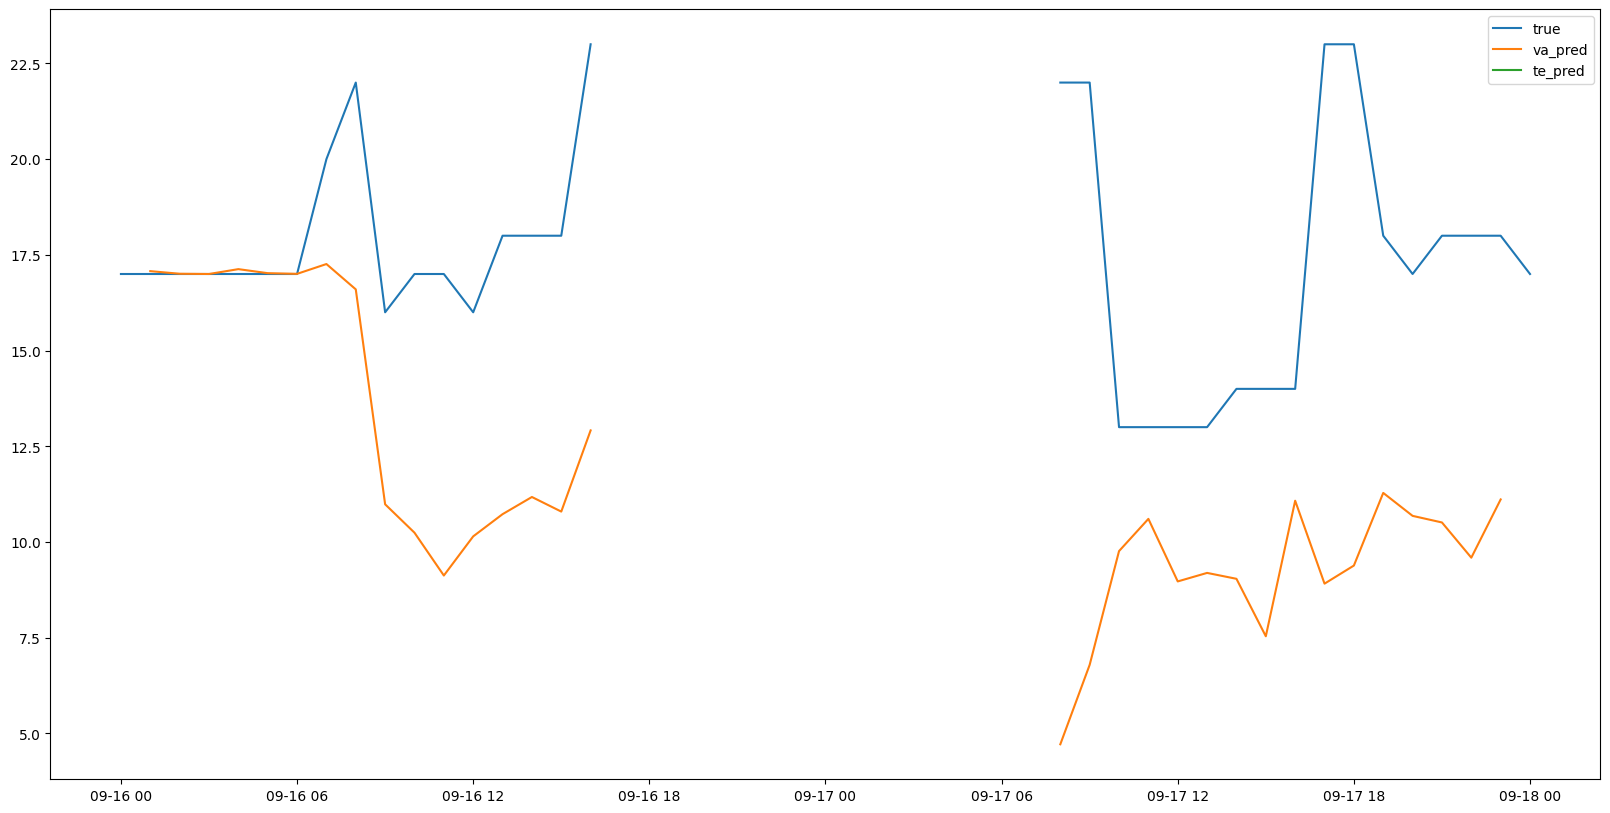

In [246]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル


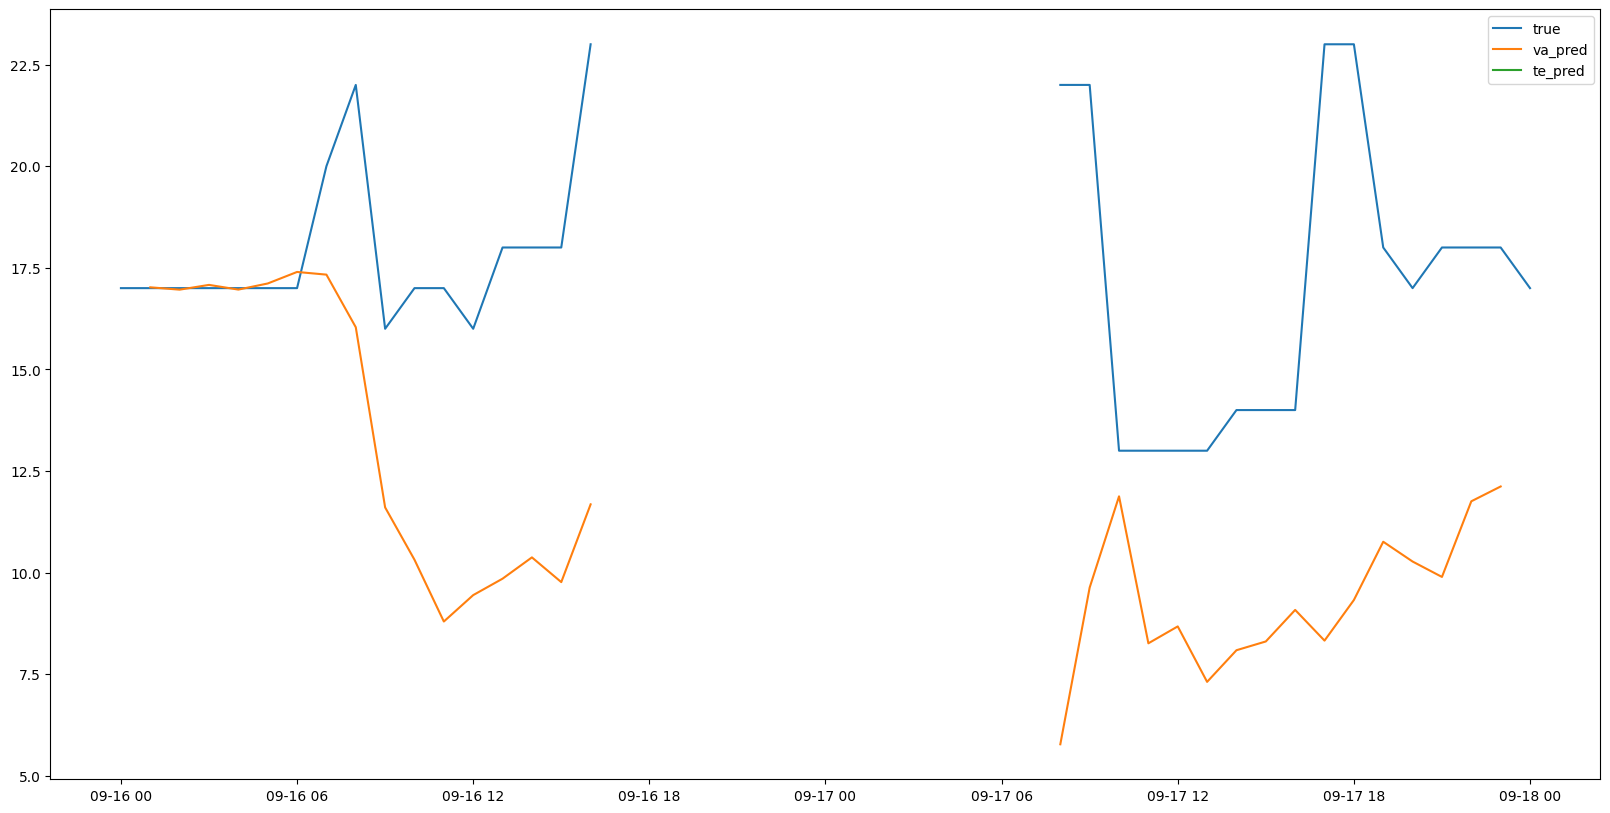

In [225]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LSTM

In [36]:
df_main_lstm_new = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lstm_new.pkl"))

In [37]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from datetime import datetime
from src.util import Logger

In [ ]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [38]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [39]:
logger = Logger(path=DIR_LOG)

In [45]:
run_name = get_run_name(model_type="lstm_mult")
# run_name = 'lstm_mult_202410091612'
run_name

'lstm_mult_202410132245'

In [46]:
model_params = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "seq_length": 24,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 5,
    "learning_rate": 0.001,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [50]:
memo = "LSTMのマルチステップ予測 学習率0.001 epoch5"
timeseries_runner = TimeseriesModelRunner(run_name, model_LSTM_mult, model_params, df_main_lstm_new, run_setting, cv_setting, logger, memo)

In [48]:
timeseries_runner.run_train_cv()

[2024-10-13 22:46:06] - lstm_mult_202410132245 - start training cv
[2024-10-13 22:46:06] - lstm_mult_202410132245 fold 2014-09-01 - start training
[2024-10-13 22:46:34] - Epoch [1/5], Loss: 0.0702
[2024-10-13 22:46:37] - Epoch [2/5], Loss: 0.0645
[2024-10-13 22:46:40] - Epoch [3/5], Loss: 0.0626
[2024-10-13 22:46:43] - Epoch [4/5], Loss: 0.0537
[2024-10-13 22:46:46] - Epoch [5/5], Loss: 0.0633
[2024-10-13 22:46:46] - lstm_mult_202410132245 fold 2014-09-01 - end training
[2024-10-13 22:46:46] - lstm_mult_202410132245 fold 2014-10-01 - start training
[2024-10-13 22:47:12] - Epoch [1/5], Loss: 0.0695
[2024-10-13 22:47:15] - Epoch [2/5], Loss: 0.0670
[2024-10-13 22:47:18] - Epoch [3/5], Loss: 0.0606
[2024-10-13 22:47:21] - Epoch [4/5], Loss: 0.0622
[2024-10-13 22:47:24] - Epoch [5/5], Loss: 0.0589
[2024-10-13 22:47:24] - lstm_mult_202410132245 fold 2014-10-01 - end training
[2024-10-13 22:47:24] - lstm_mult_202410132245 fold 2014-11-01 - start training
[2024-10-13 22:47:53] - Epoch [1/5], 

In [51]:
timeseries_runner.run_metric_cv()

[2024-10-13 22:56:00] - lstm_mult_202410132245 - start metric cv
100%|██████████| 12/12 [00:23<00:00,  1.96s/it]
memo: LSTMのマルチステップ予測 学習率0.001 epoch5
run_name:lstm_mult_202410132245	score_mean:1.6820694759435144	score0:1.7368062295534643	score1:1.8970954666554343	score2:1.6028723657051864	score3:1.6586966006150063	score4:1.6625209221003219	score5:1.5042030024725952	score6:1.7030418642643863	score7:1.622787416121049	score8:1.6177849972065284	score9:1.7419131684047715	score10:1.7938879378093695	score11:1.6432237404140626
mean: 1.6820694759435144, std: 0.09736089041824127
[2024-10-13 22:56:24] - mean: 1.6820694759435144, std: 0.09736089041824127
[2024-10-13 22:56:24] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410132245/va_pred.pkl
[2024-10-13 22:56:24] - lstm_mult_202410132245 - end metric cv


In [52]:
timeseries_runner.run_predict_cv()

[2024-10-13 22:56:24] - lstm_mult_202410132245 - start prediction cv
100%|██████████| 12/12 [00:40<00:00,  3.39s/it]
[2024-10-13 22:57:04] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410132245/te_pred.pkl
[2024-10-13 22:57:04] - lstm_mult_202410132245 - end prediction cv


In [53]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LSTMのマルチステップ予測 学習率0.001 epoch5


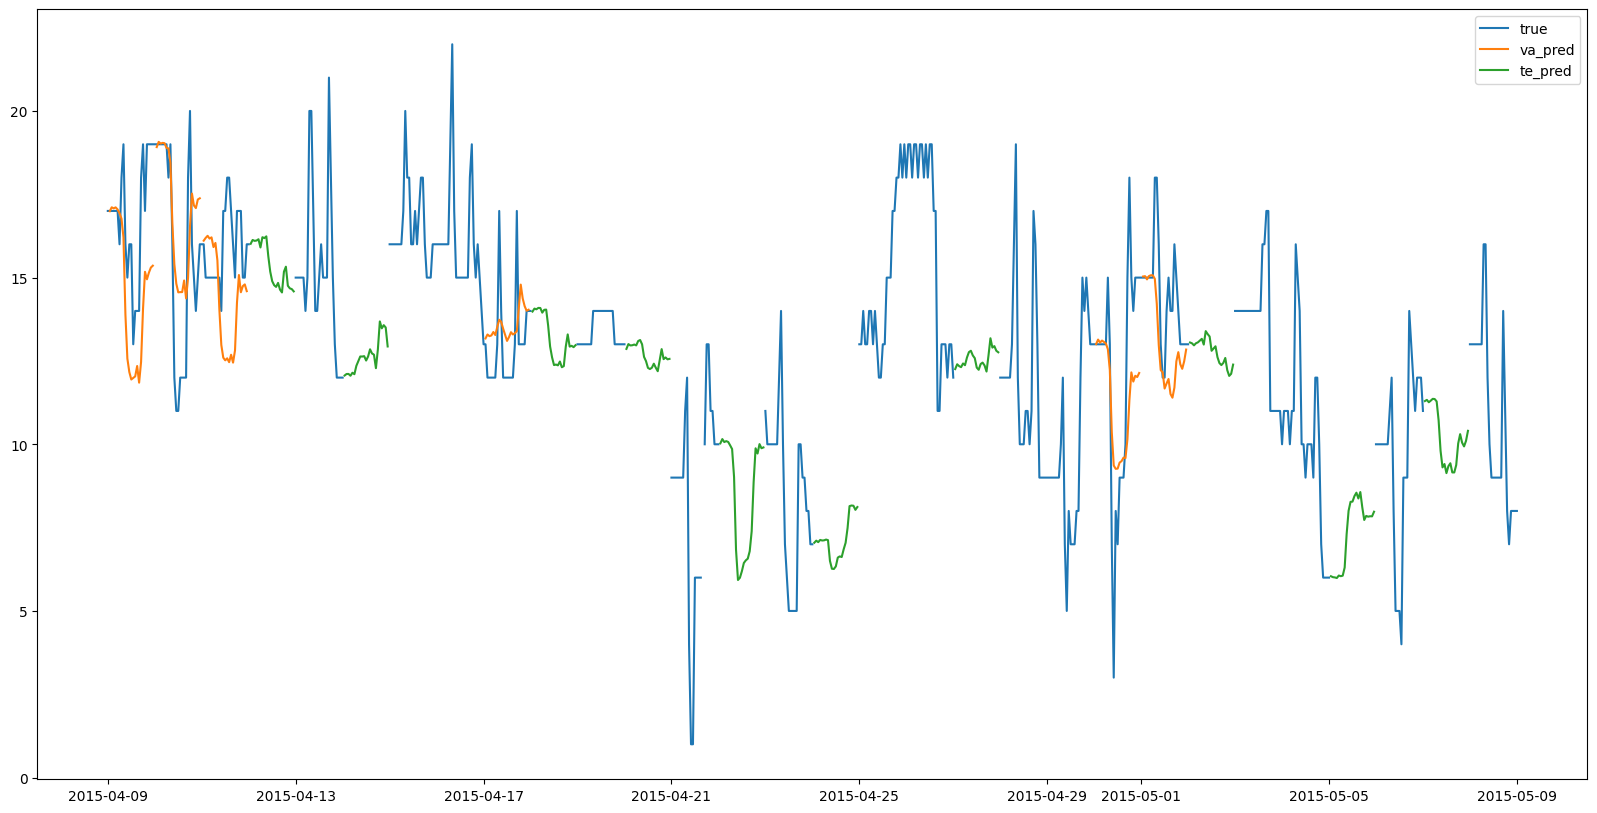

In [54]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LSTMのマルチステップ予測 学習率0.001 epoch5


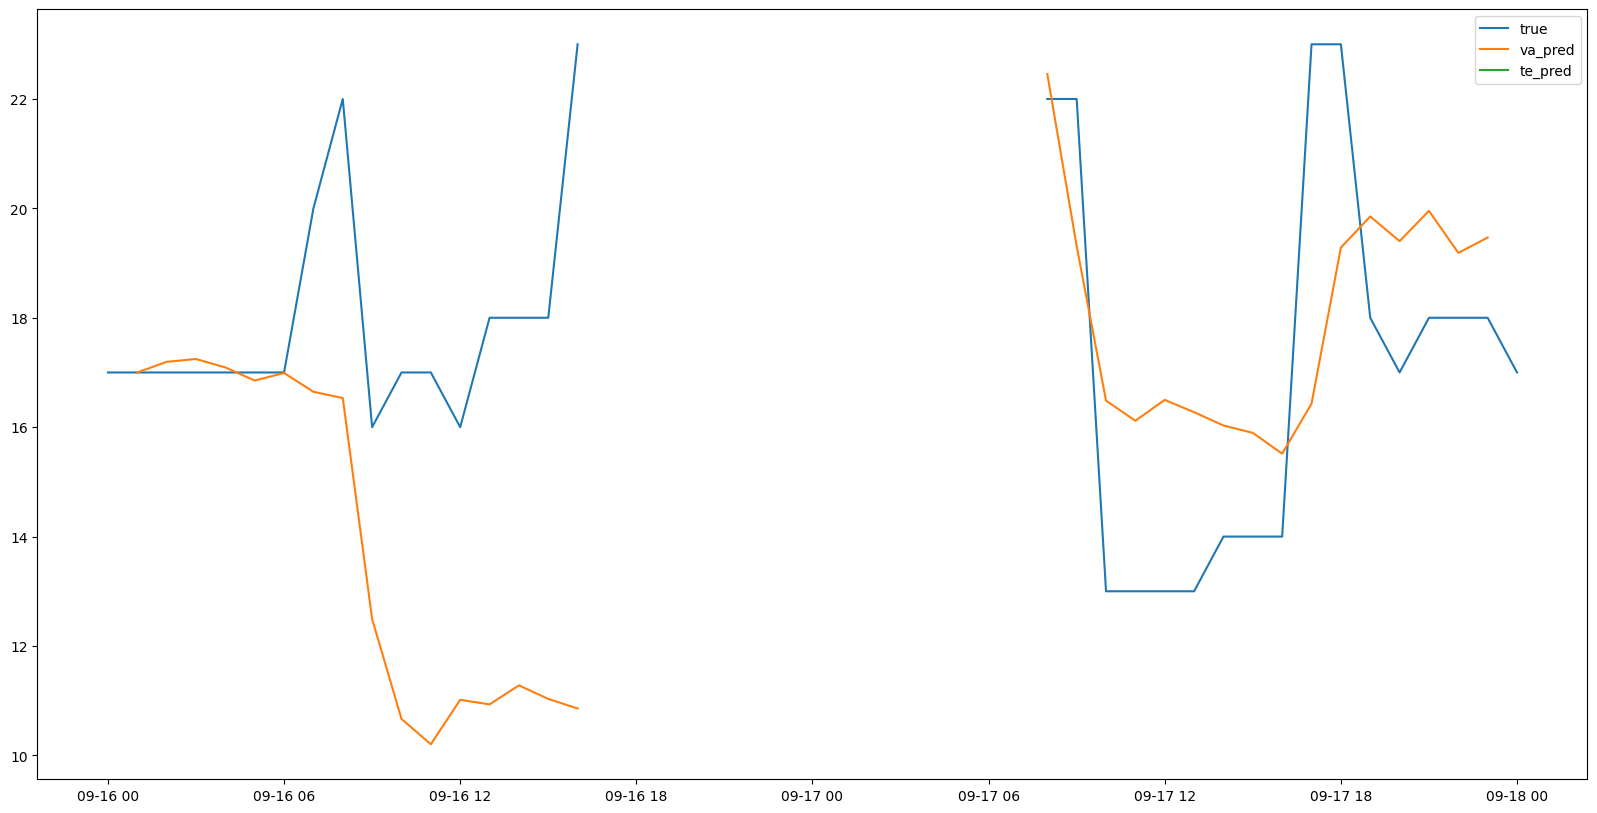

In [55]:
# 元の目的関数が欠損している部分（）
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [56]:
# 学習データ数の推移
for month in range(8, 13):
    i_fold = datetime(2014, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

for month in range(1, 9):
    i_fold = datetime(2015, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

2014-08-01 00:00:00 (22406, 24, 2)
2014-09-01 00:00:00 (24576, 24, 2)
2014-10-01 00:00:00 (25276, 24, 2)
2014-11-01 00:00:00 (26046, 24, 2)
2014-12-01 00:00:00 (26746, 24, 2)
2015-01-01 00:00:00 (27516, 24, 2)
2015-02-01 00:00:00 (28286, 24, 2)
2015-03-01 00:00:00 (28846, 24, 2)
2015-04-01 00:00:00 (29616, 24, 2)
2015-05-01 00:00:00 (30316, 24, 2)
2015-06-01 00:00:00 (31086, 24, 2)
2015-07-01 00:00:00 (31786, 24, 2)
2015-08-01 00:00:00 (32556, 24, 2)


# Submissionの作成

In [251]:
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_te_pred = pd.read_pickle(path_te_pred)
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))[["id", "datetime", "station_id", "predict"]]

In [252]:
df_submit = pd.merge(df_prep_status, df_te_pred, on=["datetime", "station_id"], how="left")

In [254]:
df_sample_submit = pd.read_csv(os.path.join(DIR_INPUT, "sample_submit.csv"), header=None, names=["id", "b_a"])
df_submit = pd.merge(df_sample_submit, df_submit, on=["id"], how="left")[["id", "bikes_available"]]
path_submit = os.path.join(DIR_SUBMISSION, f"{runner.run_name}_submit.csv")
df_submit.to_csv(path_submit, header=False, index=False)
print(path_submit)

/Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/data/submission/lgbm_multimodel_202410131842_submit.csv


In [255]:
pd.read_csv(path_submit, header=None)

,0,1
0,8761,14.999987
1,8762,15.000038
2,8763,14.999989
3,8764,14.993988
4,8765,14.965969
...,...,...
193195,1226347,9.725839
193196,1226348,9.529384
193197,1226349,10.058437
193198,1226350,10.155552


In [257]:
pd.read_csv(path_submit, header=None).isnull().sum()

0    0
1    0
dtype: int64